# Image Classification of Selected Threatened/Endangered Local Mammal Species of Singapore using Neural Networks

### how the hierarchy works:

#### taxon id -- conservation status -- species -- scientific name -- family -- order -- class

43364 CR sunda pangolin -- manis javanica -- manidae -- pholidota (keratin scales) -- mammal




45982 CR red giant flying squirrel -- petaurista petaurista -- sciuridae -- rodentia (rodents) -- mammal




44172 CR east asian/malayan porcupine -- hystrix brachyura -- hystricidae -- rodentia (rodents) -- mammal




922738 CR mainland leopard cat -- prionailurus bengalensis -- felidae -- carnivora -- mammal



41602 CR small-toothed palm civet -- arctogalidia trivirgata -- viverridae -- carnivora -- mammal

41625 CR masked palm civet -- paguma larvata -- viverridae -- carnivora -- mammal

41613 CR large indian civet -- viverra zibetha -- viverridae -- carnivora -- mammal



1638835 CR asian small-clawed otter -- lutra cinera -- mustelidae -- carnivora -- mammal

1638842 EN smooth-coated otter -- lutra perspicillata -- mustelidae -- carnivora -- mammal

https://www.nparks.gov.sg/nature/species-list/terrestrial-mammals
3rd edition of the Singapore Red Data Book (RDB3).

#### focus:
##### identifying critically endangered species in Singapore, with focus on the Sunda Pangolin, the Raffles' Banded Langur, & the Leopard Cat

##### input tensors: 100 images of birds, monkeys, cats, & anteaters
##### target tensors: 100 images classified into its animal type, sub-animal type, & species


#### Imports & Configurations 

In [30]:
# import necessary libraries/dependencies 
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import PIL
from PIL import Image, ImageOps
from io import BytesIO
import pathlib
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [13]:
# checking if query filters relevant data
# sunda pangolin
test_url1 = "https://api.inaturalist.org/v2/observations?taxon_id=43364&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data1 = requests.get(test_url1)
data1 = test_data1.json()
print("Sunda Pangolin Status Code, Total Results:", test_data1.status_code, data1["total_results"])

# red giant flying squirrel
test_url4 = "https://api.inaturalist.org/v2/observations?taxon_id=45982&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data4 = requests.get(test_url4)
data4 = test_data4.json()
print("Red Giant Flying Squirrel Status Code, Total Results:", test_data4.status_code, data4["total_results"])

# east asian/malayan porcupine
test_url7 = "https://api.inaturalist.org/v2/observations?taxon_id=44172&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data7 = requests.get(test_url7)
data7 = test_data7.json()
print("East Asian/Malayan Porcupine Status Code, Total Results:", test_data7.status_code, data7["total_results"])

# mainland leopard cat
test_url8 = "https://api.inaturalist.org/v2/observations?taxon_id=922738&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data8 = requests.get(test_url8)
data8 = test_data8.json()
print("Mainland Leopard Cat Status Code, Total Results:", test_data8.status_code, data8["total_results"])

# small-toothed palm civet
test_url9 = "https://api.inaturalist.org/v2/observations?taxon_id=41602&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data9 = requests.get(test_url9)
data9 = test_data9.json()
print("Small-toothed Palm Civet Status Code, Total Results:", test_data9.status_code, data9["total_results"])

# masked palm civet
test_url10 = "https://api.inaturalist.org/v2/observations?taxon_id=41625&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data10 = requests.get(test_url10)
data10 = test_data10.json()
print("Masked Palm Civet Status Code, Total Results:", test_data10.status_code, data10["total_results"])

# large indian civet
test_url12 = "https://api.inaturalist.org/v2/observations?taxon_id=41613&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data12 = requests.get(test_url12)
data12 = test_data12.json()
print("Large Indian Civet Status Code, Total Results:", test_data12.status_code, data12["total_results"])

# asian small-clawed otter
test_url13 = "https://api.inaturalist.org/v2/observations?taxon_id=1638835&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data13 = requests.get(test_url13)
data13 = test_data13.json()
print("Asian Small-clawed Otter Status Code, Total Results:", test_data13.status_code, data13["total_results"])

# smooth-coated otter
test_url14 = "https://api.inaturalist.org/v2/observations?taxon_id=1638842&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data14 = requests.get(test_url14)
data14 = test_data14.json()
print("Smooth-coated Otter Status Code, Total Results:", test_data14.status_code, data14["total_results"])

Sunda Pangolin Status Code, Total Results: 200 108
Red Giant Flying Squirrel Status Code, Total Results: 200 39
East Asian/Malayan Porcupine Status Code, Total Results: 200 422
Mainland Leopard Cat Status Code, Total Results: 200 156
Small-toothed Palm Civet Status Code, Total Results: 200 82
Masked Palm Civet Status Code, Total Results: 200 80
Large Indian Civet Status Code, Total Results: 200 40
Asian Small-clawed Otter Status Code, Total Results: 200 90
Smooth-coated Otter Status Code, Total Results: 200 1835


#### since some species have too few images to work with due to restrictions with the area (species not spotted in Singapore/too few sightings), change project to focus on selected mammals from singapore, but are spotted elsewhere (SEA)

species selection --> based on Singapore's conservation relevance

image dataset --> iNaturalist observations from a wider range of area (geographic)

model objective --> distinguish select mammal species

one limitation may be the background (area in which animal is spotted); distribution/domain difference

since excluded the red-cheeked flying squirrel, the horsfield's flying squirrel, the shew-faced ground squirrel, the brown spiny rat, & the malay civet as the available observations on iNaturalist is not enough for eventually training the model

### Testing on one image

In [25]:
# pull dataset from URL using RISON
api_url = "https://api.inaturalist.org/v2/observations?photos=true&photo_license=cc0,cc-by&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# api_url = "https://api.inaturalist.org/v2/observations?fields=all"


# GET request to URL
response = requests.get(api_url)

# status code for HTTPS
print(response.status_code)

# inspect first index result
data = response.json()
print(data["results"][0])

200
{'uuid': 'ee80e4cb-6280-4ecc-91ae-02cc6cee6dbf', 'id': 398363259, 'photos': [{'id': 730767280, 'url': 'https://inaturalist-open-data.s3.amazonaws.com/photos/730767280/square.jpg', 'license_code': 'cc-by', 'attribution': '(c) Filip Żuchowski, some rights reserved (CC BY)'}]}


In [26]:
photo = data["results"][0]["photos"][0]
print(photo.keys())

dict_keys(['id', 'url', 'license_code', 'attribution'])


In [27]:
# replacing square.jpg with medium.jpg for better quality
if "url" in photo.keys():
    new_url = photo["url"].replace("square", "medium")

print(new_url)

https://inaturalist-open-data.s3.amazonaws.com/photos/730767280/medium.jpg


In [28]:
# fetch image
test_image = requests.get(new_url)
print(test_image.status_code)
print(test_image.headers.get("content-type"))

200
image/jpeg


#### Define Image Data specifications 

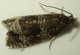

In [19]:
# preprocess & show image
image = Image.open(BytesIO(test_image.content))

w, h = image.size
new_w = 80
new_h = int(h * (new_w / w))

image = image.convert("RGB")
image = image.resize((new_w, new_h))

display(image)

In [20]:
# convert image into Numpy array
image_arr = np.array(image)
print(image_arr.shape)

(55, 80, 3)


This shows that the image is a 3D tensor, & has a height of 178, width of 250, & 3 colour channels (RGB).

In [21]:
# check pixel range
print("data type: %s" % image_arr.dtype)
print("min: %.3f, max: %.3f" % (image_arr.min(), image_arr.max()))

data type: uint8
min: 8.000, max: 227.000


In [22]:
# normalisation on image
image_arr = image_arr.astype("float32")
image_arr /= 255.0
print("min: %.3f, max: %.3f" % (image_arr.min(), image_arr.max()))

min: 0.031, max: 0.890


In [23]:
# flatten 3D tensor into a 1D tensor
flatten_arr = image_arr.flatten()

print("3D tensor:\n", image_arr)
print("flattened array:\n", flatten_arr)

3D tensor:
 [[[0.8784314  0.8862745  0.8039216 ]
  [0.8784314  0.8862745  0.8039216 ]
  [0.8745098  0.8862745  0.80784315]
  ...
  [0.7882353  0.79607844 0.7137255 ]
  [0.78431374 0.7921569  0.7058824 ]
  [0.78039217 0.7882353  0.7019608 ]]

 [[0.88235295 0.8901961  0.80784315]
  [0.88235295 0.8901961  0.80784315]
  [0.8784314  0.8901961  0.80784315]
  ...
  [0.78431374 0.7921569  0.70980394]
  [0.78431374 0.7921569  0.7058824 ]
  [0.7764706  0.7921569  0.7019608 ]]

 [[0.88235295 0.8901961  0.80784315]
  [0.88235295 0.8901961  0.80784315]
  [0.8784314  0.8901961  0.80784315]
  ...
  [0.7882353  0.79607844 0.70980394]
  [0.78039217 0.7921569  0.70980394]
  [0.7764706  0.7921569  0.7019608 ]]

 ...

 [[0.83137256 0.8352941  0.7647059 ]
  [0.8235294  0.827451   0.75686276]
  [0.81960785 0.8235294  0.75686276]
  ...
  [0.72156864 0.73333335 0.6509804 ]
  [0.7176471  0.7294118  0.64705884]
  [0.7137255  0.7254902  0.6431373 ]]

 [[0.827451   0.83137256 0.75686276]
  [0.81960785 0.8235294  

### Preprocess all data for ML task

In [31]:
# list of dictionaries for the species
# taxon id -- conservation status -- species -- scientific name -- family -- order

species_list = [
                    {
                        "species_name": "sunda pangolin",
                        "scientific_name": "manis javanica",
                        "animal_family": "manidae",
                        "animal_order": "pholidota",
                        "taxon_id": 43364,
                        "conservation_status": "CR",
                        "usable_count": 108
                    },
                    {
                        "species_name": "red giant flying squirrel",
                        "scientific_name": "petaurista petaurista",
                        "animal_family": "sciuridae",
                        "animal_order": "rodentia",
                        "taxon_id": 45982,
                        "conservation_status": "CR",
                        "usable_count": 39
                    },
                    {
                        "species_name": "east asian/malayan porcupine",
                        "scientific_name": "hystrix brachyura",
                        "animal_family": "hystricidae",
                        "animal_order": "rodentia",
                        "taxon_id": 44172,
                        "conservation_status": "CR",
                        "usable_count": 422
                    },
                    {
                        "species_name": "mainland leopard cat",
                        "scientific_name": "prionailurus bengalensis",
                        "animal_family": "felidae",
                        "animal_order": "carnivora",
                        "taxon_id": 922738,
                        "conservation_status": "CR",
                        "usable_count": 156 
                    },
                    {
                        "species_name": "small-tooth palm civet",
                        "scientific_name": "arctogalidia trivirgata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41602,
                        "conservation_status": "CR",
                        "usable_count": 82  
                    },
                    {
                        "species_name": "masked palm civet",
                        "scientific_name": "paguma larvata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41625,
                        "conservation_status": "CR",
                        "usable_count": 80  
                    },
                    {
                        "species_name": "large indian civet",
                        "scientific_name": "viverra zibetha",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41613,
                        "conservation_status": "CR",
                        "usable_count": 40  
                    },
                    {
                        "species_name": "asian small-clawed otter",
                        "scientific_name": "lutra cinera",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638835,
                        "conservation_status": "CR",
                        "usable_count": 90  
                    },
                    {
                        "species_name": "smooth-coated otter",
                        "scientific_name": "lutra perspicillata",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638842,
                        "conservation_status": "EN",
                        "usable_count": 1835  
                    }
                ]

for animal in species_list:
    print(animal["species_name"], animal["usable_count"])

sunda pangolin 108
red giant flying squirrel 39
east asian/malayan porcupine 422
mainland leopard cat 156
small-tooth palm civet 82
masked palm civet 80
large indian civet 40
asian small-clawed otter 90
smooth-coated otter 1835


#### We will now test the above with 3 observations

In [32]:
# resize & convert image to 80 x 80, rgb
def resize_photo(images):
    images = images.convert("RGB")
    target_size = (80, 80)

    padded_imgs = ImageOps.pad(images, 
                              target_size, 
                              color = "white", 
                              centering = (0.5, 0.5))

    return padded_imgs

In [33]:
# convert images to arrays
def img_to_arr(padded_imgs):
    imgs_arr = np.array(padded_imgs)

    print(imgs_arr.shape)

    return imgs_arr

In [34]:
# normalise images to [0, 1]
def normal_img(imgs_arr):
    imgs_arr = imgs_arr.astype("float32")
    imgs_arr /= 255.0

    return imgs_arr

In [35]:
# flatten 3D tensor into a 1D tensor
def flatten_arr(imgs_arr):
    flattened_arrs = imgs_arr.flatten()

    return flattened_arrs

In [36]:
# test 3 images through the functions


# resized = resize_photo(images)
# imgs_arr = img_to_arr(resized)
# normalised = normal_img(imgs_arr)
# flat = flatten_arr(normalised)

# print("Resized Dimensions:", resized.size)
# print("Image Array Shape:", imgs_arr.shape)
# print("min: %.3f, max: %.3f", normalised.min(), normalised.max())
# print("Flattened Array Shape:", flat.shape)

In [62]:
# API request with dict key
def req_api(animal):
    page_index = 1
    # for collecting observations
    collected_obs = []
    max_obs = 20

    url = f"https://api.inaturalist.org/v2/observations?photos=true&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
    
    while len(collected_obs) < max_obs:
        query_params = {"taxon_id": animal["taxon_id"], "page": page_index}
        
        # GET request to URL
        response = requests.get(url, params = query_params)
        data = response.json()
        
        page_results = data["results"]

        if not page_results: # no more available observations
            break

        collected_obs += page_results

        print("Page Number:", page_index,
             "| Retrieved:", len(page_results),
             "| Total Observations Collected:", len(collected_obs)
             )
        
        page_index += 1

    trim_obs = collected_obs[:max_obs]
    del collected_obs[max_obs:]

    print(
        "Animal:", animal["species_name"],
        "| Final Observations:", len(trim_obs)
    )
    return trim_obs

int_to_order = {
    0: "pholidota",
    1: "rodentia",
    2: "carnivora"
}
        
order_to_int = {
    v: k for k, v in int_to_order.items()
}

# empty lists for converting animal orders to int
x_order = []
y_order = []

for animal in species_list:
    animal_info = req_api(animal)
    observations = animal_info

    animal_order = animal["animal_order"]
    order_int = order_to_int[animal_order]

    print(
        "\nProcessing:", animal["species_name"],
        "| Images:", len(observations),
        "| Order:", order_int
    )
    
    # display & preprocessing 3 images (test)
    for observation in observations:
        if not observation["photos"]: # first photo from each observation
            continue

        photo_info = observation["photos"][0]
    
        if "url" not in photo_info:
            continue

        new_url = photo_info["url"].replace("square", "medium")

        try:
            # download image
            img_response = requests.get(new_url)

            if img_response.status_code != 200:
                continue
    
            images = Image.open(BytesIO(img_response.content))
            
            rs_observation = resize_photo(images)
            obs_arr = img_to_arr(rs_observation)
            normalised = normal_img(obs_arr)
            flat = flatten_arr(normalised)
    
            if flat.shape != (19200, ):
                continue
            
            x_order.append(flat) # append flattened vector into x_order
            y_order.append(order_int) # append order classification into y_order

        except Exception as e:
            print("Skipped Image:", e)

# convert lists to NumPy arrays after collection of observation's finished
x_order_arr = np.array(x_order, dtype = "float32")
y_order_arr = np.array(y_order, dtype = "int32")

print("\nFinal Order Dataset")
print("X shape:", x_order_arr.shape)
print("Y shape:", y_order_arr.shape)

print(
    "Pholidota:", np.sum(y_order_arr == 0),
    "Rodentia:", np.sum(y_order_arr == 1),
    "Carnivora:", np.sum(y_order_arr == 2)
)

Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Animal: sunda pangolin | Final Observations: 20

Processing: sunda pangolin | Images: 20 | Order: 0
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Animal: red giant flying squirrel | Final Observations: 20

Processing: red giant flying squirrel | Images: 20 | Order: 1
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Animal: east asian/malayan porcupine | Final Observations: 20

Processing: east asian/malayan porcup

In [63]:
# train / validation / test
from sklearn.model_selection import train_test_split

# 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    x_order_arr,
    y_order_arr,
    test_size=0.30,
    random_state=42,
    stratify=y_order_arr
)

# split remaining 30% equally -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (126, 19200) (126,)
Validation: (27, 19200) (27,)
Test: (27, 19200) (27,)


In [67]:
# inspect split before modelling
print("Training classes:", np.bincount(y_train))
print("Validation classes:", np.bincount(y_val))
print("Test classes:", np.bincount(y_test))

Training classes: [14 28 84]
Validation classes: [ 3  6 18]
Test classes: [ 3  6 18]


In [68]:
# baseline Dense model
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(19200,)),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        3,
        activation="softmax"
    )
])

In [69]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │     1,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,229,059 (4.69 MB)

 Trainable params: 1,229,059 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [72]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.5079 - loss: 8.8037 - val_accuracy: 0.6667 - val_loss: 5.7739
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5476 - loss: 3.7239 - val_accuracy: 0.3333 - val_loss: 1.4463
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5238 - loss: 1.2265 - val_accuracy: 0.7407 - val_loss: 0.8734
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6746 - loss: 1.0300 - val_accuracy: 0.6667 - val_loss: 0.9552
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 1.0279 - val_accuracy: 0.6667 - val_loss: 0.8677
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6667 - loss: 0.9136 - val_accuracy: 0.6667 - val_loss: 0.9050
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6667 - loss: 0.9335 - val_accuracy: 0.6667 - val_loss: 0.8444
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 0.9768 - val_accuracy: 0.6667 - val_loss: 0.8312
